# Stage 2 — complete experiment comparison

Scan the complete Stage 2 artifact tree, exclude incomplete LOSO runs, export a compact thesis-ready table, show one matched representative comparison, and generate the Section 4.2.3 subject-level heterogeneous-benefit figure.


In [1]:
from pathlib import Path
import json, os, subprocess, sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():  # VS Code may start in notebooks/
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)
SRC_DIR = ROOT / 'src'
sys.path.insert(0, str(SRC_DIR))
SUBPROCESS_ENV = os.environ.copy()
SUBPROCESS_ENV['PYTHONPATH'] = str(SRC_DIR) + os.pathsep + SUBPROCESS_ENV.get('PYTHONPATH', '')

ARTIFACTS = Path('artifacts/stage2')
OUTPUT = Path('results/tables/stage2/fusion_comparison')
EXPECTED_SUBJECTS = 154
REPRESENTATIVE_METHOD = 'residual'   # concatenation, film, or residual
REPRESENTATIVE_STRATEGY = 'finetune' # finetune or scratch
HETEROGENEITY_METHOD = 'residual'    # final Section 4.2.3 method
HETEROGENEITY_FALLBACK_METHOD = 'concatenation'  # whole-matrix preview only

ARTIFACTS, REPRESENTATIVE_METHOD, REPRESENTATIVE_STRATEGY, HETEROGENEITY_METHOD


(PosixPath('artifacts/stage2'), 'residual', 'finetune', 'residual')

## Build the complete comparison

Every completed configuration is identified by feature source, fusion method, training strategy, and target. The primary paired quantity is ΔRMSE = experiment RMSE − baseline RMSE for the same held-out subject; negative values favor the experiment. Runs with fewer than `EXPECTED_SUBJECTS` unique folds are reported and skipped.


In [2]:
command = [
    sys.executable, '-m', 'subject_nirs.stage2.comparison',
    '--root', str(ARTIFACTS),
    '--output-dir', str(OUTPUT),
    '--expected-subjects', str(EXPECTED_SUBJECTS),
    '--representative-method', REPRESENTATIVE_METHOD,
    '--representative-strategy', REPRESENTATIVE_STRATEGY,
    '--heterogeneity-method', HETEROGENEITY_METHOD,
    '--no-pdf',
]
if HETEROGENEITY_FALLBACK_METHOD is not None:
    command += ['--heterogeneity-fallback-method', HETEROGENEITY_FALLBACK_METHOD]
subprocess.run(command, cwd=ROOT, env=SUBPROCESS_ENV, check=True)


Loaded DRS-only baseline      target=hc   folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/baseline/hc
Loaded DRS-only baseline      target=sto2 folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/baseline/sto2
Loaded DTOF descriptor | Concatenation | Fine-tuning target=hc   folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/concatenation/finetune/dtof/hc
Loaded DTOF descriptor | Concatenation | Fine-tuning target=sto2 folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/concatenation/finetune/dtof/sto2
Loaded Tissue-thickness feature | Concatenation | Fine-tuning target=hc   folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifacts/stage2/concatenation/finetune/metadata/hc
Loaded Tissue-thickness feature | Concatenation | Fine-tuning target=sto2 folds=154 from /media/md703/PNY_Gen4_4TB/YC/Research/final_refactored/artifact

CompletedProcess(args=['/home/md703/.conda/envs/yc_ae/bin/python', '-m', 'subject_nirs.stage2.comparison', '--root', 'artifacts/stage2', '--output-dir', 'results/tables/stage2/fusion_comparison', '--expected-subjects', '154', '--representative-method', 'residual', '--representative-strategy', 'finetune', '--heterogeneity-method', 'residual', '--no-pdf', '--heterogeneity-fallback-method', 'concatenation'], returncode=0)

## Display the thesis-ready table and representative figure

`final_experiment_table.csv` retains numeric columns for later analysis. The formatted CSV is convenient for direct thesis-table review.


,target,feature_source,fusion_method,training_strategy,experiment,n_subjects,error unit,"RMSE median [Q1, Q3]","Bias median [Q1, Q3]","paired ΔRMSE median [Q1, Q3]",improved subjects (%),paired rank-biserial,Holm-adjusted p
0,tHb,—,—,Scratch,DRS-only baseline,154,μM,"14.03 [10.52, 17.89]","1.071 [-9.824, 8.306]",—,—,—,—
1,tHb,DTOF descriptor,Concatenation,Scratch,DTOF descriptor | Concatenation | Scratch,154,μM,"14.68 [10.66, 17.82]","-1.946 [-8.873, 6.436]","+0.1192 [-3.55, +3.683]",48.7,-0.031,1
2,tHb,DTOF descriptor,Concatenation,Fine-tuning,DTOF descriptor | Concatenation | Fine-tuning,154,μM,"12.78 [9.916, 17.13]","-0.5122 [-7.35, 7.703]","-0.6468 [-3.016, +0.8654]",63.0,+0.342,0.00186
3,tHb,DTOF descriptor,FiLM,Scratch,DTOF descriptor | FiLM | Scratch,154,μM,"14.25 [11.28, 17.87]","-0.9799 [-8.873, 6.548]","+0.06014 [-3.932, +3.68]",48.1,-0.017,1
4,tHb,DTOF descriptor,FiLM,Fine-tuning,DTOF descriptor | FiLM | Fine-tuning,154,μM,"12.92 [9.77, 17.43]","-0.4621 [-8.234, 8.344]","-0.7264 [-2.829, +0.8518]",62.3,+0.304,0.00551
5,tHb,DTOF descriptor,Gated residual,Scratch,DTOF descriptor | Gated residual | Scratch,154,μM,"14.11 [11.65, 17.72]","-0.5548 [-8.565, 6.969]","+0.02557 [-3.685, +3.765]",50.0,-0.016,1
6,tHb,DTOF descriptor,Gated residual,Fine-tuning,DTOF descriptor (shuffle) | Gated residual | F...,154,μM,"12.68 [10.23, 17.11]","-0.1721 [-8.223, 6.368]","-0.3998 [-2.234, +0.6212]",63.0,+0.334,0.00226
7,tHb,DTOF descriptor,Gated residual,Fine-tuning,DTOF descriptor (zero) | Gated residual | Fine...,154,μM,"12.86 [10.28, 17.25]","-0.1909 [-8.118, 7.244]","-0.5923 [-2.099, +0.4121]",62.3,+0.377,0.000537
8,tHb,DTOF descriptor,Gated residual,Fine-tuning,DTOF descriptor | Gated residual | Fine-tuning,154,μM,"12.49 [9.851, 17.16]","-0.363 [-7.559, 7.375]","-0.7652 [-3.001, +0.6986]",63.0,+0.367,0.000766
9,tHb,Tissue-thickness feature,Concatenation,Scratch,Tissue-thickness feature | Concatenation | Scr...,154,μM,"12.68 [9.901, 15.7]","-0.3068 [-7.513, 7.341]","-0.7298 [-4.272, +1.713]",59.7,+0.308,0.00551


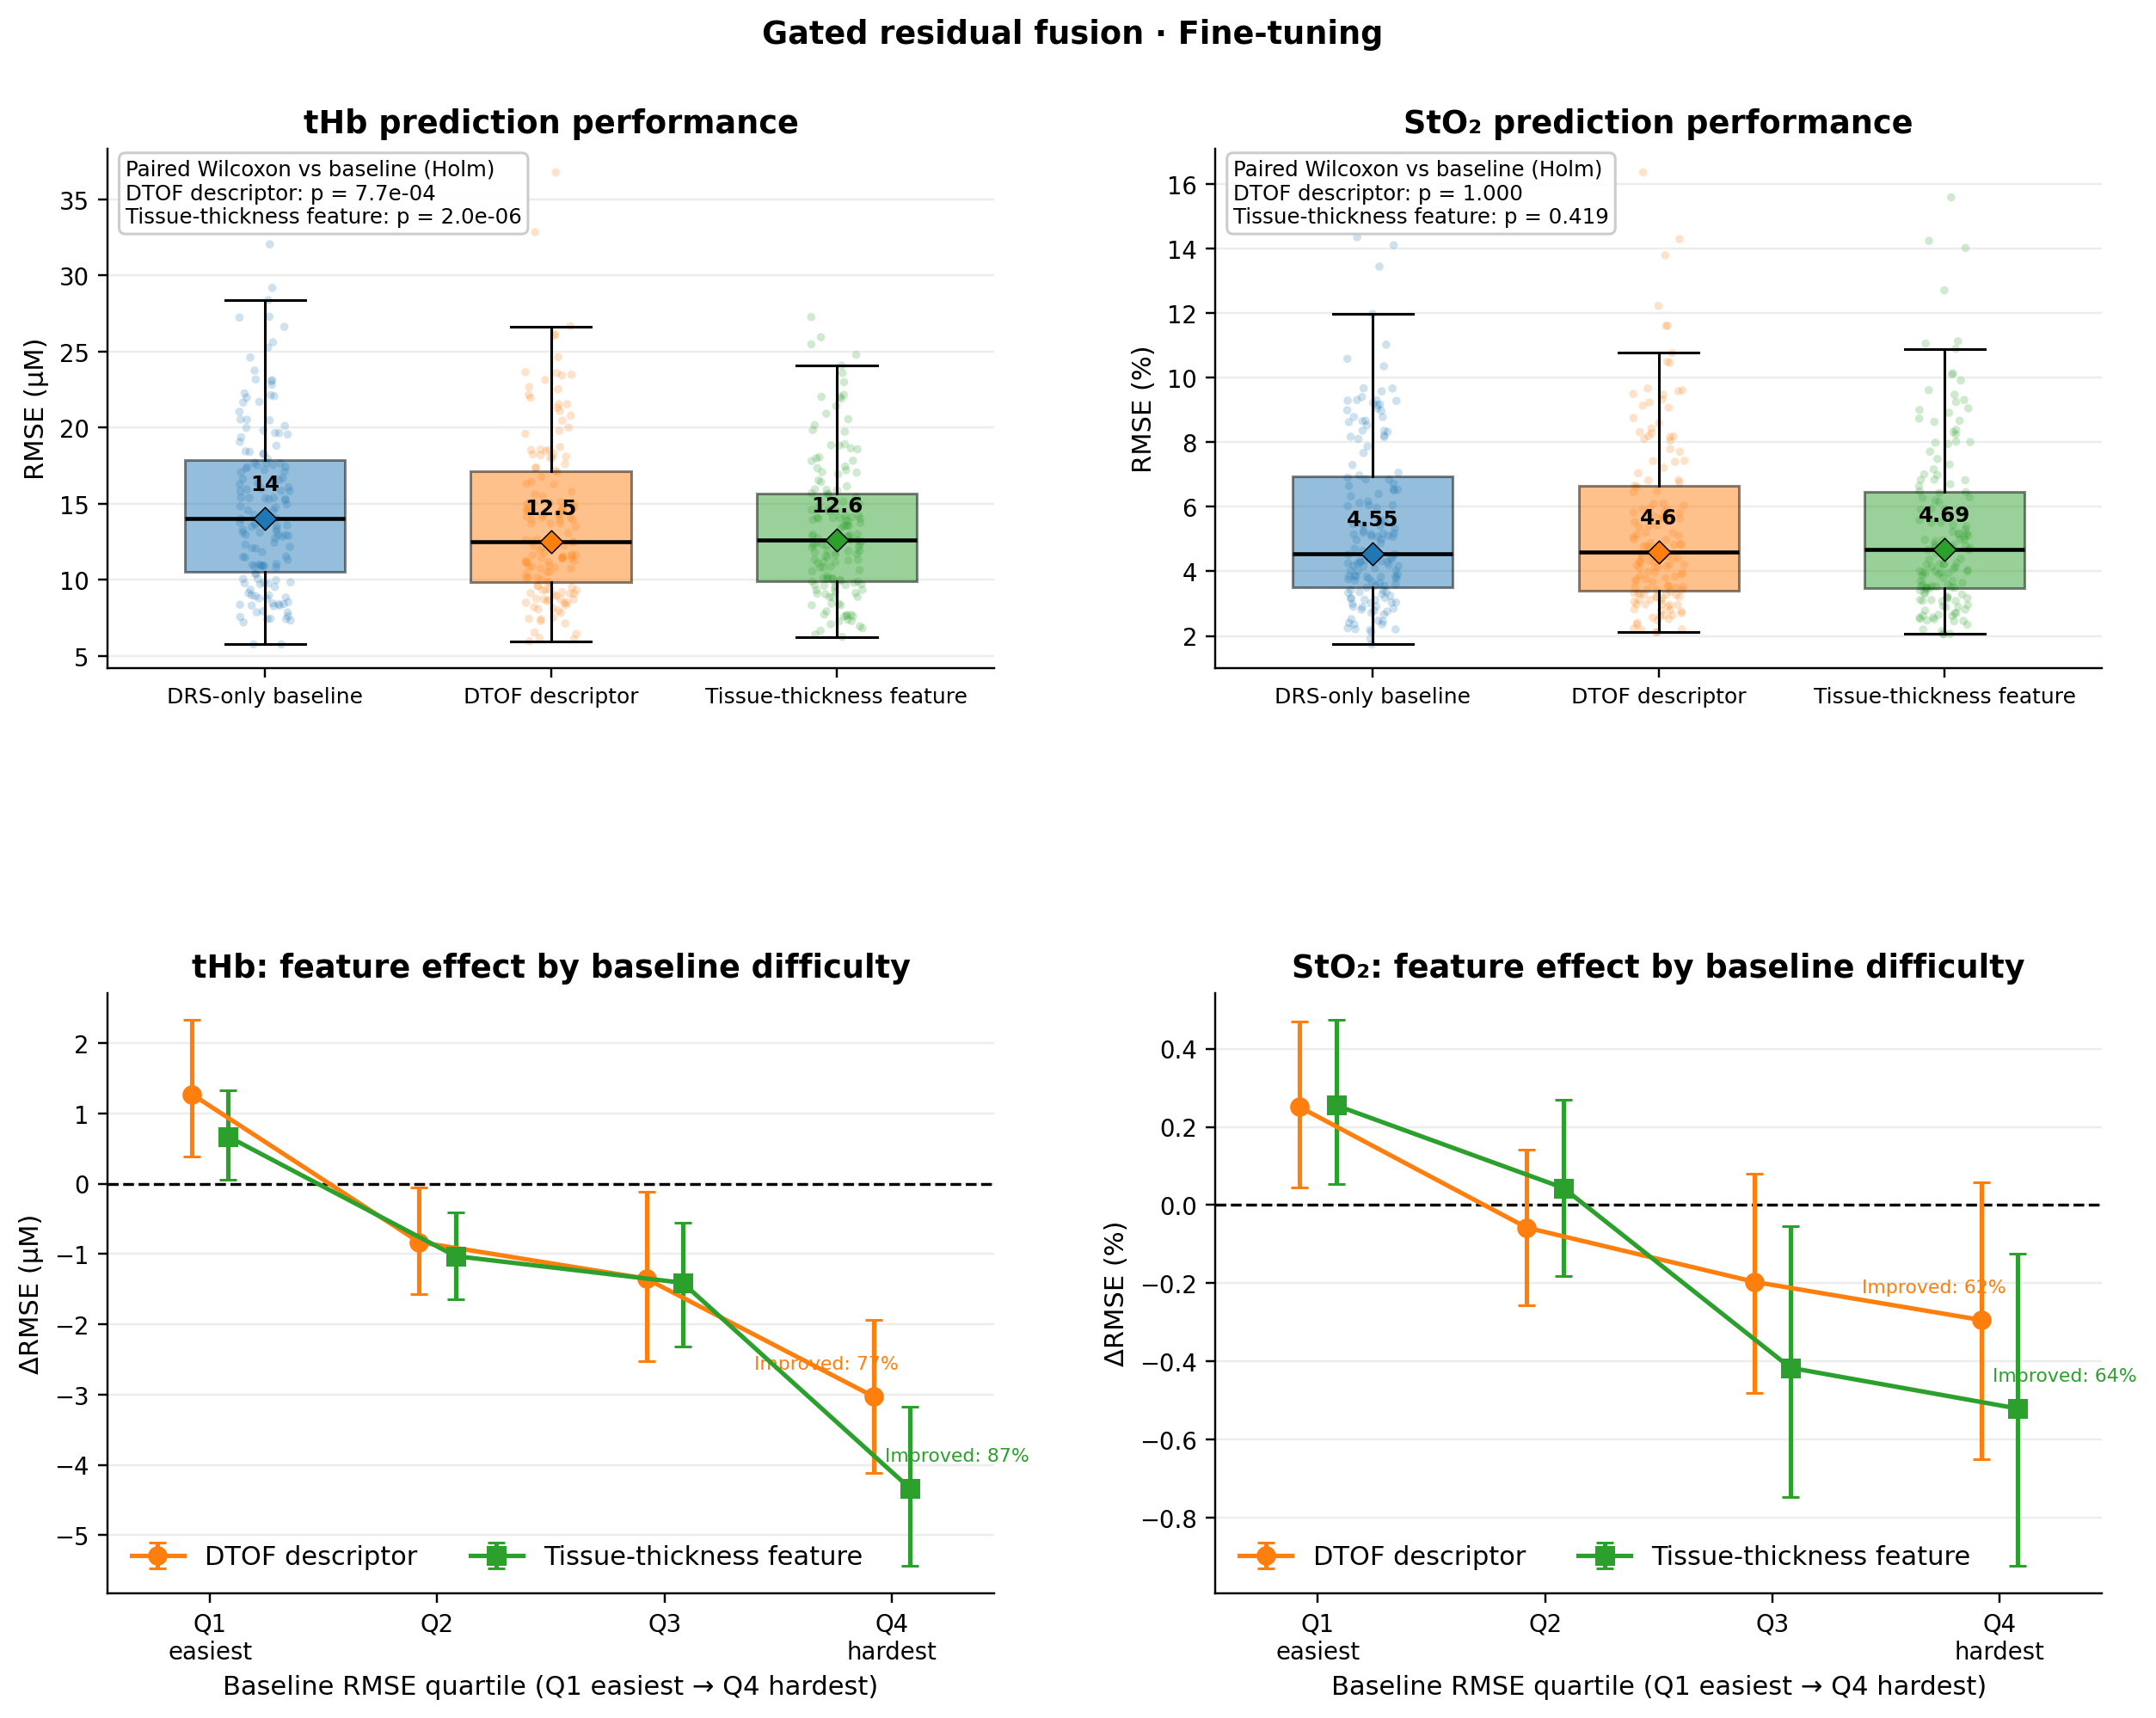

,target,feature_source,fusion_method,training_strategy,experiment,n_subjects,rmse_median,rmse_q1,rmse_q3,bias_median,bias_q1,bias_q3,n_paired_subjects,delta_rmse_median,delta_rmse_q1,delta_rmse_q3,improved_subjects_pct,paired_rank_biserial,wilcoxon_p,wilcoxon_p_holm
0,hc,baseline,none,scratch,DRS-only baseline,154,14.033874,10.521772,17.889792,1.071402,-9.824305,8.305751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hc,latent,concatenation,scratch,DTOF descriptor | Concatenation | Scratch,154,14.682302,10.664454,17.824935,-1.946035,-8.873470,6.435624,154.0,0.119215,-3.550199,3.683188,48.701299,-0.030750,7.406397e-01,1.000000
2,hc,latent,concatenation,finetune,DTOF descriptor | Concatenation | Fine-tuning,154,12.782431,9.915918,17.133410,-0.512225,-7.350297,7.702928,154.0,-0.646770,-3.015849,0.865395,62.987013,0.341935,2.325454e-04,0.001860
3,hc,latent,film,scratch,DTOF descriptor | FiLM | Scratch,154,14.254025,11.275131,17.871347,-0.979889,-8.873167,6.548067,154.0,0.060141,-3.931794,3.680245,48.051948,-0.016674,8.575585e-01,1.000000
4,hc,latent,film,finetune,DTOF descriptor | FiLM | Fine-tuning,154,12.922002,9.769799,17.431146,-0.462089,-8.233754,8.344159,154.0,-0.726385,-2.828506,0.851774,62.337662,0.303561,1.084358e-03,0.005507
5,hc,latent,residual,scratch,DTOF descriptor | Gated residual | Scratch,154,14.112516,11.645718,17.718287,-0.554815,-8.564817,6.969272,154.0,0.025566,-3.685359,3.764796,50.000000,-0.016339,8.603919e-01,1.000000
6,hc,latent,residual,finetune,DTOF descriptor (shuffle) | Gated residual | F...,154,12.676540,10.233500,17.107550,-0.172107,-8.222721,6.367571,154.0,-0.399769,-2.233737,0.621186,62.987013,0.334059,3.231814e-04,0.002262
7,hc,latent,residual,finetune,DTOF descriptor (zero) | Gated residual | Fine...,154,12.855494,10.277107,17.252862,-0.190925,-8.117846,7.244073,154.0,-0.592338,-2.098901,0.412058,62.337662,0.377294,4.878643e-05,0.000537
8,hc,latent,residual,finetune,DTOF descriptor | Gated residual | Fine-tuning,154,12.492620,9.851041,17.161531,-0.362965,-7.558792,7.375318,154.0,-0.765199,-3.001275,0.698623,62.987013,0.367407,7.655423e-05,0.000766
9,hc,metadata,concatenation,scratch,Tissue-thickness feature | Concatenation | Scr...,154,12.684021,9.901166,15.703347,-0.306837,-7.512717,7.341361,154.0,-0.729839,-4.271741,1.713163,59.740260,0.307918,9.178338e-04,0.005507


In [3]:
numeric_table = pd.read_csv(OUTPUT / 'final_experiment_table.csv')
formatted_table = pd.read_csv(OUTPUT / 'final_experiment_table_formatted.csv')
display(formatted_table)
display(Image(filename=str(OUTPUT / 'representative_loso_comparison.png'), width=1300))

# Keep the numeric table available for sorting/filtering in later cells.
numeric_table


## Section 4.2.3 — subject-level heterogeneous benefit

The four panels fix one fusion operator and compare DTOF descriptor versus tissue-thickness feature across scratch and baseline-checkpoint fine-tuning. Columns are tHb and StO₂; rows are training strategies. Q1–Q4 are assigned once per target from baseline held-out-subject RMSE, and negative ΔRMSE indicates improvement.

If the requested gated-residual matrix is incomplete, the notebook uses one complete concatenation matrix for a clearly labelled layout preview. It never mixes operators across missing cells.


{'requested_method': 'residual',
 'fallback_method': 'concatenation',
 'selected_method': 'residual',
 'is_preview': False,
 'requested_method_missing_cells': [],
 'generated': True,
 'image': 'heterogeneous_benefit_residual.png',
 'summary': 'heterogeneous_benefit_residual.csv'}

,target,fusion_method,training_strategy,feature_source,difficulty_quartile,n_subjects,delta_RMSE_median,delta_RMSE_Q1,delta_RMSE_Q3,improved_subjects_pct
0,hc,residual,scratch,latent,Q1,39,4.086245,0.094679,7.303340,23.076923
1,hc,residual,scratch,latent,Q2,38,2.111720,-0.532754,3.774910,31.578947
2,hc,residual,scratch,latent,Q3,38,-2.466984,-4.297828,1.708545,63.157895
3,hc,residual,scratch,latent,Q4,39,-5.113743,-8.328061,-0.882010,82.051282
4,hc,residual,scratch,metadata,Q1,39,0.895941,-0.977625,2.768999,35.897436
5,hc,residual,scratch,metadata,Q2,38,-0.979744,-3.413247,0.483258,63.157895
6,hc,residual,scratch,metadata,Q3,38,-1.661779,-5.120214,2.198788,63.157895
7,hc,residual,scratch,metadata,Q4,39,-6.004223,-7.881395,-1.634536,87.179487
8,hc,residual,finetune,latent,Q1,39,0.422378,-0.652969,1.953693,38.461538
9,hc,residual,finetune,latent,Q2,38,-0.888432,-2.298547,0.582649,65.789474


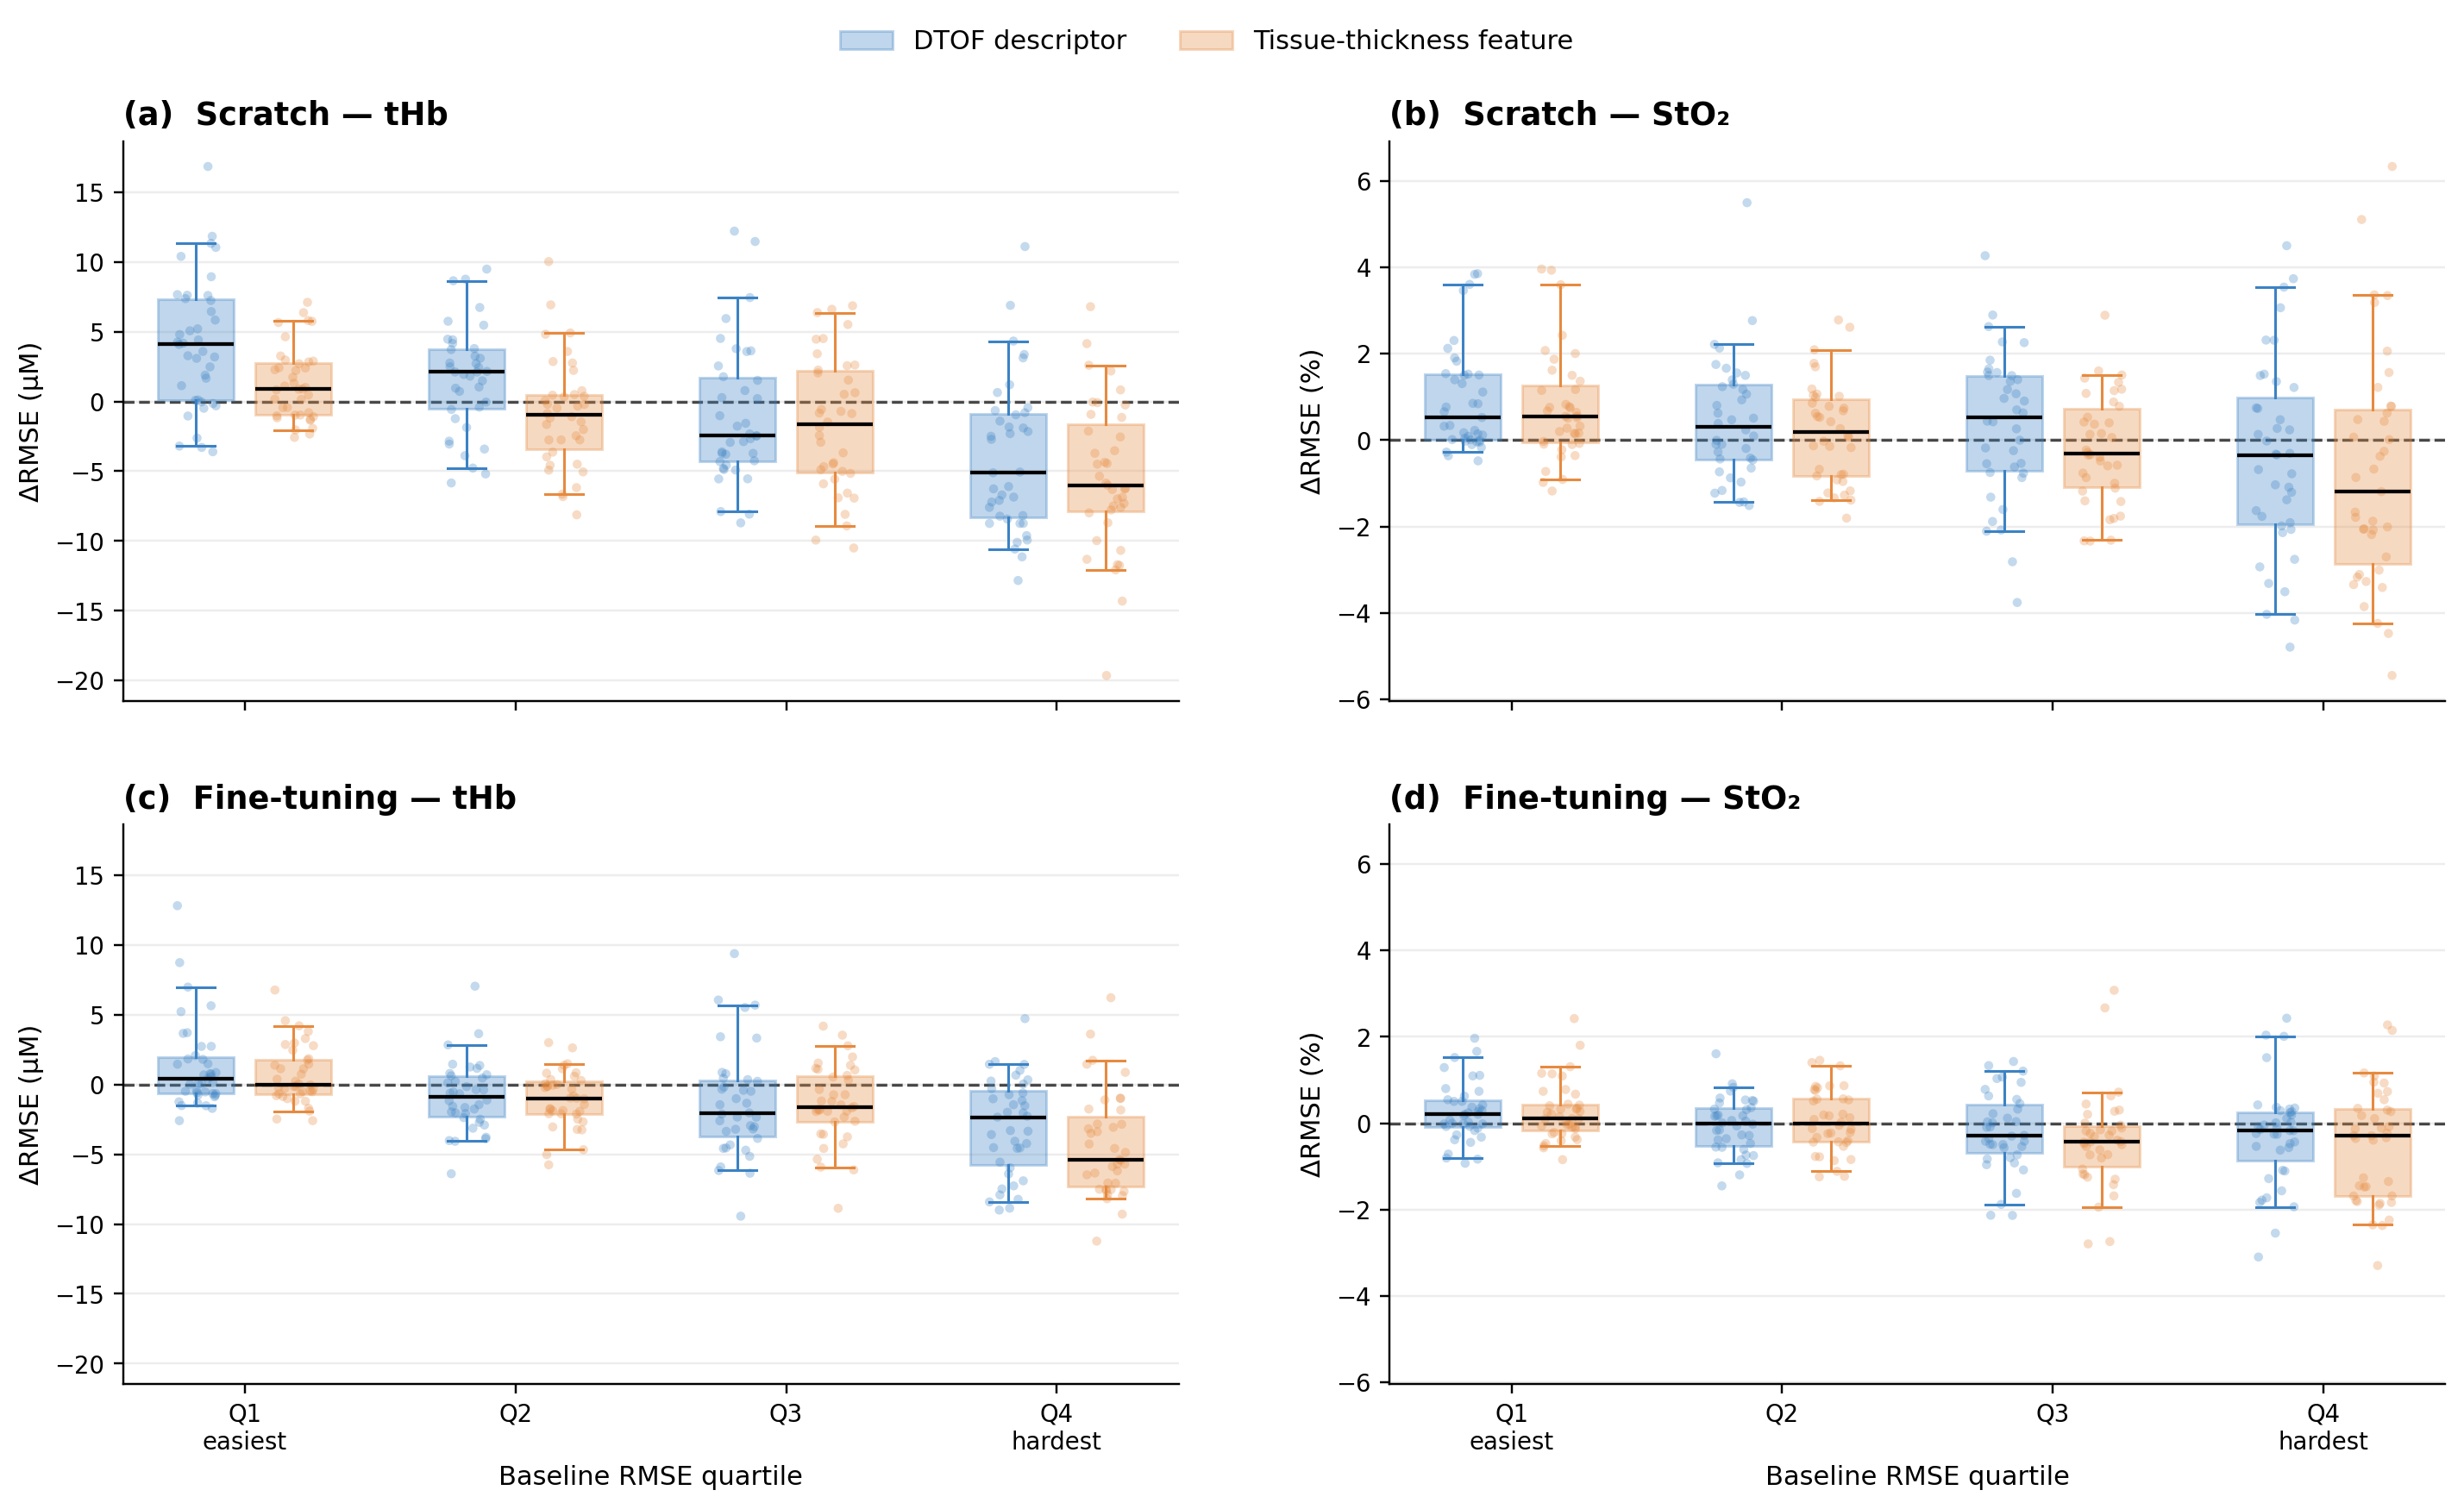

In [4]:
manifest_path = OUTPUT / 'heterogeneous_benefit_manifest.json'
heterogeneity_manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
display(heterogeneity_manifest)

if heterogeneity_manifest['generated']:
    if heterogeneity_manifest['is_preview']:
        display(Markdown(
            '**Preview only:** the requested gated-residual matrix is incomplete; '
            'the complete concatenation matrix is used for layout verification.'
        ))
    heterogeneity_table = pd.read_csv(OUTPUT / heterogeneity_manifest['summary'])
    display(heterogeneity_table)
    display(Image(filename=str(OUTPUT / heterogeneity_manifest['image']), width=1400))
else:
    display(Markdown('**Figure not generated:** no complete requested or fallback matrix.'))
